# Stable Matching for Kidney Donor–Patient Assignment

## Problem story
We model a kidney matching problem with two sets of agents:
- **Patients**
- **Donors**

Each patient has a ranked list of donors based on compatibility or suitability.

We want to assign donors to patients such that:
1. Each patient receives **at most one donor**,
2. Each donor is assigned to **at most one patient**,
3. The final assignment is **stable**.

A matching is **stable** if there is **no blocking pair**, meaning there does not exist a patient–donor pair who would both prefer each other over their current assignments.

## Dataset handling
We started from an online kidney dataset containing raw medical and operational information.

To make it suitable for stable matching, we preprocessed it into a compact rankings dataset:
- Each row represents one **patient**
- Columns `Rank_1`, `Rank_2`, ..., `Rank_k` contain donor IDs ordered from most preferred to least preferred

The dataset only provided **patient-side preferences**, so donor-side rankings were constructed from these rankings:
- donors prefer patients who rank them more highly

This gives us a complete two-sided preference structure, which is required for a stable matching model.

In [53]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

# Install only if needed
# Pkg.add("JuMP")
# Pkg.add("HiGHS")
# Pkg.add("CSV")
# Pkg.add("DataFrames")
# Pkg.add("Plots")

using CSV, DataFrames, Random
using JuMP, HiGHS
using Plots

  Activating project at `c:\Users\chinm\OneDrive - Singapore University of Technology and Design\TERM 4\40.002 Optimization\1D project`


In [54]:
df = CSV.read("patient_rankings_output.csv", DataFrame)

# df columns look like: patient_id, Rank_1, Rank_2, ..., Rank_1001
rank_cols = filter(c -> startswith(String(c), "Rank_"), names(df))

println("Rows (patients): ", nrow(df))
println("Ranking columns: ", length(rank_cols))

Rows (patients): 1000
Ranking columns: 1001


## Instance selection
To satisfy the project requirement of solving a **medium-sized instance**, we do not necessarily need to use the entire dataset.

Instead, we choose a large but still computationally manageable instance:
- Sample **1000 patients**
- Keep the top **100 donor preferences** per patient
- Cap the donor pool so that the bipartite graph remains visually balanced

This keeps the instance realistic, large enough to be meaningful, and still solvable within presentation-friendly runtime.

In [55]:
# =========================
# 2) Choose a medium instance (balanced patients and donors)
# =========================
Random.seed!(1)

nA = 1000   # number of patients sampled
k  = 100    # number of preferences per patient

# sample patients
patient_rows = randperm(nrow(df))[1:nA]
dfA = df[patient_rows, :]

# collect donor IDs appearing in top-k preferences of sampled patients
donor_ids_set = Set{String}()
for i in 1:nA
    for j in 1:min(k, length(rank_cols))
        d = dfA[i, rank_cols[j]]
        if !ismissing(d)
            push!(donor_ids_set, String(d))
        end
    end
end

# convert set to list
all_donors = sort(collect(donor_ids_set))

# keep only as many donors as patients (balanced graph)
nB_target = nA
donor_ids = all_donors[1:min(nB_target, length(all_donors))]
nB = length(donor_ids)

println("Sampled patients: ", nA)
println("Donors selected: ", nB)

# Index sets
A = 1:nA
B = 1:nB

# Map IDs <-> indices
patient_id = [String(dfA[i, :patient_id]) for i in A]
donor_id   = donor_ids

patient_index = Dict(patient_id[a] => a for a in A)
donor_index   = Dict(donor_id[b]   => b for b in B)

Sampled patients: 1000
Donors selected: 1000


Dict{String, Int64} with 1000 entries:
  "D891" => 882
  "D204" => 120
  "D743" => 718
  "D267" => 189
  "D344" => 275
  "D12"  => 26
  "D99"  => 991
  "D214" => 131
  "D806" => 788
  "D475" => 420
  "D240" => 160
  "D814" => 797
  "D484" => 430
  "D73"  => 703
  "D95"  => 947
  "D452" => 395
  "D509" => 458
  "D279" => 202
  "D190" => 104
  ⋮      => ⋮

In [56]:
# =========================
# 3) Build patient preference lists prefA[a] = list of donor indices
# =========================
prefA = Vector{Vector{Int}}(undef, nA)

for a in A
    prefs = Int[]
    for j in 1:min(k, length(rank_cols))
        d = dfA[a, rank_cols[j]]
        if !ismissing(d)
            ds = String(d)
            if haskey(donor_index, ds)
                push!(prefs, donor_index[ds])
            end
        end
    end
    # remove duplicates just in case
    prefA[a] = unique(prefs)
end

## Donor preference construction
The dataset only provides patient-to-donor rankings.

Stable matching requires preferences on **both sides**, so we construct donor rankings from the patient rankings:
- If many patients rank a donor highly, that donor is assumed to prefer those patients more

This is a practical way to derive donor preferences while staying consistent with the structure of the processed dataset.

In [57]:
# =========================
# 4) Derive donor preferences from patient rankings
#    Rule: donors prefer patients who rank them higher.
# =========================
# Build a lookup: posA[a,b] = rank position (1..k) if donor b appears in a's top-k; else large
BIG = 10^9
posA = fill(BIG, nA, nB)

for a in A
    for (pos, b) in enumerate(prefA[a])
        posA[a, b] = pos
    end
end

# For each donor b, rank patients by posA[a,b] (smaller = better)
# Keep top-k patients for donor to keep density manageable
prefB = Vector{Vector{Int}}(undef, nB)

for b in B
    scored = [(a, posA[a,b]) for a in A if posA[a,b] < BIG]
    sort!(scored, by=x->x[2])  # ascending (rank 1 best)
    prefB[b] = [x[1] for x in scored[1:min(k, length(scored))]]
end

In [58]:
# =========================
# 5) Build rank tables rankA[a,b], rankB[b,a]
# =========================
rankA = fill(BIG, nA, nB)
for a in A
    for (r, b) in enumerate(prefA[a])
        rankA[a,b] = r
    end
end

rankB = fill(BIG, nB, nA)
for b in B
    for (r, a) in enumerate(prefB[b])
        rankB[b,a] = r
    end
end

# Mutually acceptable pairs P (appear in both top-k lists)
P = [(a,b) for a in A, b in B if rankA[a,b] < BIG && rankB[b,a] < BIG]
println("Mutually acceptable pairs |P|: ", length(P))

Mutually acceptable pairs |P|: 96222


In [59]:
# =========================
# 6) Precompute "better-than" sets for stability constraints
# =========================
betterB_forA = Dict{Tuple{Int,Int}, Vector{Int}}()  # (a,b) -> b' preferred by a over b
betterA_forB = Dict{Tuple{Int,Int}, Vector{Int}}()  # (b,a) -> a' preferred by b over a

for (a,b) in P
    rb = rankA[a,b]
    betterB_forA[(a,b)] = [bp for bp in prefA[a] if rankA[a,bp] < rb && rankB[bp,a] < BIG]

    ra = rankB[b,a]
    betterA_forB[(b,a)] = [ap for ap in prefB[b] if rankB[b,ap] < ra && rankA[ap,b] < BIG]
end

## MILP formulation

### Decision variable
For each mutually acceptable pair $(a,b)$,

$$
x_{a,b} =
\begin{cases}
1 & \text{if patient } a \text{ is matched to donor } b \\
0 & \text{otherwise}
\end{cases}
$$

### Matching constraints
- Each patient matched to at most one donor
- Each donor matched to at most one patient

### Stability constraints
For every mutually acceptable pair $(a,b)$, at least one of the following must hold:
- $a$ is matched to $b$  
- $a$ is matched to someone they prefer more than $b$  
- $b$ is matched to someone they prefer more than $a$

This prevents blocking pairs.

### Objective
Maximize the total number of matched patient–donor pairs.

In [60]:
# =========================
# 7) JuMP MILP model
# =========================
model = Model(HiGHS.Optimizer)

@variable(model, x[P], Bin)

# Matching constraints (one-to-one, allowing unmatched)
@constraint(model, [a in A], sum(x[(a,b)] for b in B if (a,b) in P) <= 1)
@constraint(model, [b in B], sum(x[(a,b)] for a in A if (a,b) in P) <= 1)

# Stability constraints (no blocking pairs)
for (a,b) in P
    @constraint(model,
        x[(a,b)] +
        sum(x[(a,bp)] for bp in betterB_forA[(a,b)] if (a,bp) in P) +
        sum(x[(ap,b)] for ap in betterA_forB[(b,a)] if (ap,b) in P) >= 1
    )
end

# Objective: maximize number of matches 
@objective(model, Max, sum(x[p] for p in P))

# Solve
optimize!(model)

println("\nStatus: ", termination_status(model))
println("Objective (#matches): ", objective_value(model))

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 98222 rows; 96222 cols; 9468101 nonzeros; 96222 integer variables (96222 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+00]
Presolving model
40160 rows, 12668 cols, 780120 nonzeros  5s
0 rows, 0 cols, 0 nonzeros  5s
Presolve reductions: rows 0(-98222); columns 0(-96222); nonzeros 0(-9468101) - Reduced to empty
Presolve: Optimal

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds              | 

## Why the output is stable
The model explicitly includes **no-blocking-pair constraints**.

These constraints mathematically encode stability.
Therefore, if the solver returns a feasible optimal solution, the resulting matching is stable **by construction**.

In [61]:
# =========================
# 8) Sanity checks
# =========================

# Check no patient is matched more than once
for a in A
    patient_match_count = sum(value(x[p]) for p in P if p[1] == a)
    if patient_match_count > 1.01
        println("ERROR: patient ", a, " matched multiple times")
    end
end

# Check no donor is matched more than once
for b in B
    donor_match_count = sum(value(x[p]) for p in P if p[2] == b)
    if donor_match_count > 1.01
        println("ERROR: donor ", b, " matched multiple times")
    end
end

## Visualization 1: Histogram of assigned donor ranks
This plot shows how good the assignments are from the **patient perspective**.

A lower assigned rank means the patient received a more preferred donor.

Histogram:



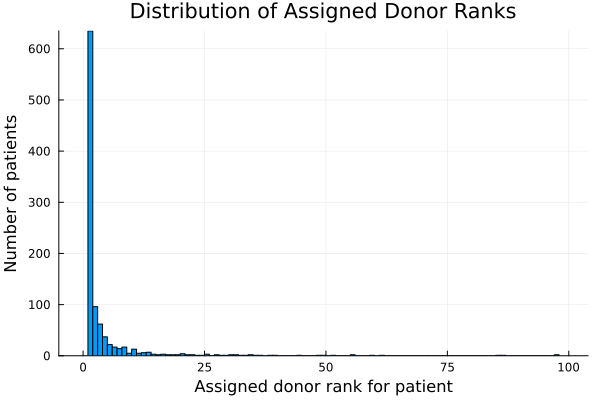

In [62]:
using Plots

matched_rank = Int[]

for a in A
    assigned = 0
    for b in B
        if (a,b) in P && value(x[(a,b)]) > 0.5
            assigned = rankA[a,b]
            break
        end
    end
    if assigned > 0
        push!(matched_rank, assigned)
    end
end

histogram(
    matched_rank,
    bins=1:maximum(matched_rank)+1,
    xlabel="Assigned donor rank for patient",
    ylabel="Number of patients",
    title="Distribution of Assigned Donor Ranks",
    legend=false
)

## Visualization 2: Bipartite graph of the matching
Patients are shown on the left and donors on the right.
Each line represents a matched pair in the stable matching solution.

Bipartite:

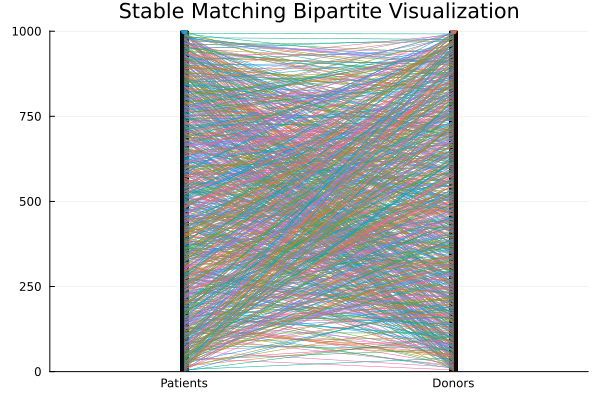

In [63]:
using Plots

matched_pairs = [(a,b) for (a,b) in P if value(x[(a,b)]) > 0.5]

x_left = fill(1, length(A))
y_left = collect(1:length(A))

x_right = fill(2, length(B))
y_right = collect(1:length(B))

plot(legend=false, xlim=(0.5, 2.5), ylim=(0, max(length(A), length(B))+1),
     xticks=([1,2], ["Patients","Donors"]),
     title="Stable Matching Bipartite Visualization")

scatter!(x_left, y_left)
scatter!(x_right, y_right)

for (a,b) in matched_pairs
    plot!([1,2], [a,b], lw=0.5)
end

display(plot!())